# Project: Predicting Life Expectancy (CRISP-DM)

## Phase 1: Business Understanding

### What is this project about?
I'm using a dataset from the World Health Organization (WHO) that has health and economic data for 193 countries from the years 2000 to 2015. My main goal here is to figure out what actually makes people live longer. Is it a country's money (GDP)? Is it vaccines? Or maybe schooling?

### How am I going to solve this?
Since I want to predict "Life Expectancy" (which is just a continuous number, like 72.5 years), this is a **Regression** problem. I plan to use a simple model like **Multiple Linear Regression**. I really want to understand the math behind it and see how the model connects all these different features together.

### How will I check if my model is doing a good job?
To see if my model is actually learning, I'll use two simple metrics:
* **MAE (Mean Absolute Error):** This will tell me, on average, how many years my prediction is off by.
* **R-Squared:** This will show me how much of the life expectancy is actually explained by the data I provided.

### My final goal
At the end of this notebook, I don't just want a working code. I want to look at the model's weights to see which feature had the biggest impact on life expectancy. I want to understand the root causes.

## Phase 2: Data Understanding

Now it's time to load my dataset and see what I am dealing with. I will use Pandas
My goals for this step are:
1. Load the CSV file.
2. Look at the first few rows just to get a feel for the data.
3. Check the shape (how many rows and columns).
4. See if there are any missing values (nulls) that I need to fix later.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/Life Expectancy Data.csv')

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
print("--- First 5 rows of the dataset ---")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

--- First 5 rows of the dataset ---


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12

### 2.1.EDA

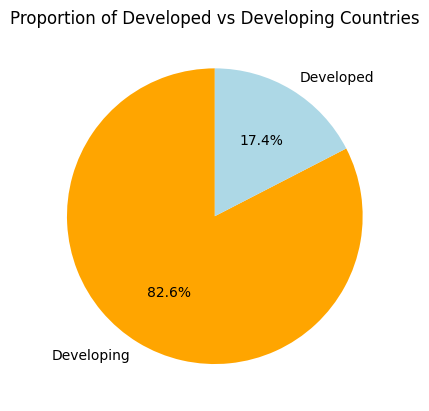

In [ ]:
status_counts = df['Status'].value_counts()

plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90, colors=['orange', 'lightblue'])

plt.title('Proportion of Developed vs Developing Countries')
plt.show()

#### 2.1.1 Data Cleaning

In [ ]:
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
Population,22.191967
Hepatitis B,18.822328
GDP,15.248468
Total expenditure,7.692308
Alcohol,6.603131
Income composition of resources,5.684139
Schooling,5.547992
thinness 1-19 years,1.157250
thinness 5-9 years,1.157250
BMI,1.157250


Missing values in target variable

In [ ]:
df[df["Life expectancy"].isna()]

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
624,Cook Islands,2013,Developing,NaN,NaN,0,0.01,0.000000,98.0,0,...,98.0,3.58,98.0,0.1,NaN,NaN,0.1,0.1,NaN,NaN
769,Dominica,2013,Developing,NaN,NaN,0,0.01,11.419555,96.0,0,...,96.0,5.58,96.0,0.1,722.756650,NaN,2.7,2.6,0.721,12.7
1650,Marshall Islands,2013,Developing,NaN,NaN,0,0.01,871.878317,8.0,0,...,79.0,17.24,79.0,0.1,3617.752354,NaN,0.1,0.1,NaN,0.0
1715,Monaco,2013,Developing,NaN,NaN,0,0.01,0.000000,99.0,0,...,99.0,4.30,99.0,0.1,NaN,NaN,NaN,NaN,NaN,NaN
1812,Nauru,2013,Developing,NaN,NaN,0,0.01,15.606596,87.0,0,...,87.0,4.65,87.0,0.1,136.183210,NaN,0.1,0.1,NaN,9.6
1909,Niue,2013,Developing,NaN,NaN,0,0.01,0.000000,99.0,0,...,99.0,7.20,99.0,0.1,NaN,NaN,0.1,0.1,NaN,NaN
1958,Palau,2013,Developing,NaN,NaN,0,NaN,344.690631,99.0,0,...,99.0,9.27,99.0,0.1,1932.122370,292.0,0.1,0.1,0.779,14.2
2167,Saint Kitts and Nevis,2013,Developing,NaN,NaN,0,8.54,0.000000,97.0,0,...,96.0,6.14,96.0,0.1,NaN,NaN,3.7,3.6,0.749,13.4
2216,San Marino,2013,Developing,NaN,NaN,0,0.01,0.000000,69.0,0,...,69.0,6.50,69.0,0.1,NaN,NaN,NaN,NaN,NaN,15.1
2713,Tuvalu,2013,Developing,NaN,NaN,0,0.01,78.281203,9.0,0,...,9.0,16.61,9.0,0.1,3542.135890,1819.0,0.2,0.1,NaN,0.0


In [ ]:
df["Life expectancy"].isna().sum()

np.int64(10)

In [ ]:
# Since Life expectancy is the target, I recommend dropping those 10 rows, rather than imputing the target.

df = df.dropna(subset=["Life expectancy"])

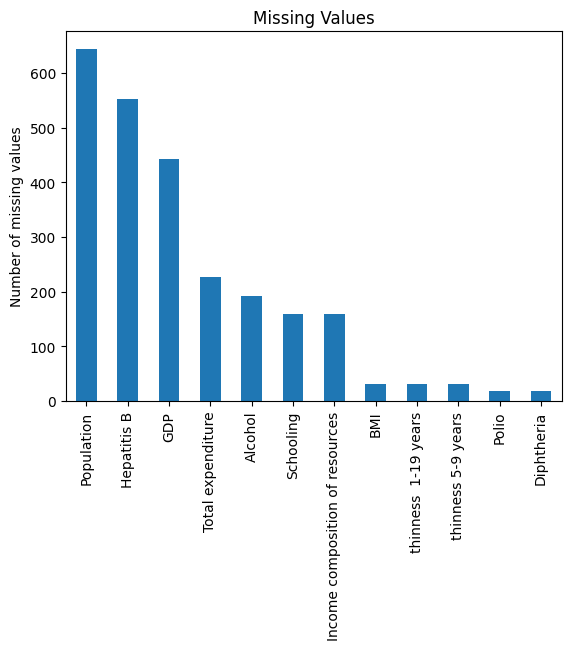

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing.plot(kind="bar")
plt.ylabel("Number of missing values")
plt.title("Missing Values")
plt.show()

In [ ]:
#Removing unnecessary spaces in column names
df.columns = df.columns.str.strip()

In [ ]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

#### 2.1.2 Univariate Analysis

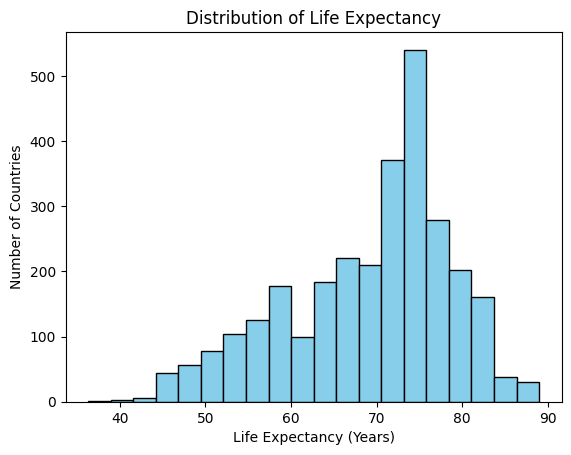

In [ ]:
df['Life expectancy'].plot(kind='hist', bins=20, color='skyblue', edgecolor='black')

plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy (Years)')
plt.ylabel('Number of Countries')
plt.show()

#### 2.1.3 Bivariate Analysis

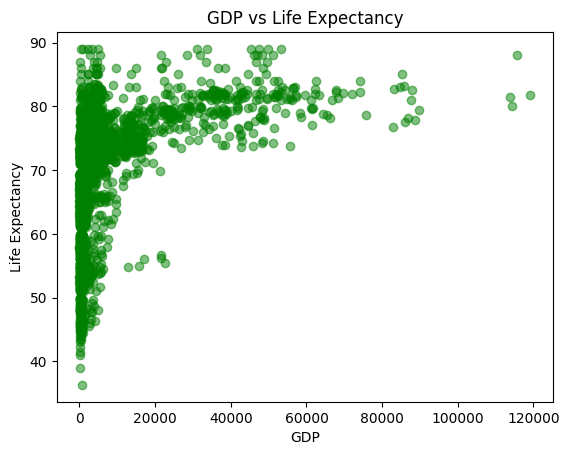

In [ ]:
plt.scatter(df['GDP'], df['Life expectancy'], alpha=0.5, color='green')

plt.title('GDP vs Life Expectancy')
plt.xlabel('GDP')
plt.ylabel('Life Expectancy')
plt.show()

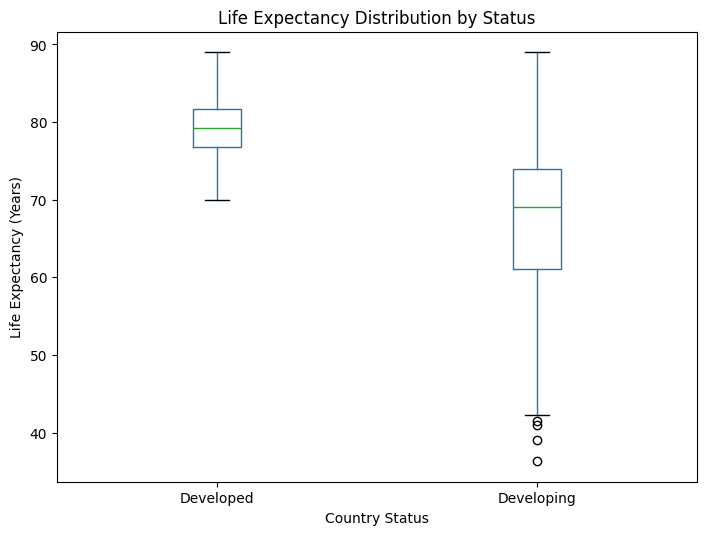

In [ ]:
df.boxplot(column='Life expectancy', by='Status', figsize=(8, 6), grid=False)

plt.title('Life Expectancy Distribution by Status')
plt.suptitle('')
plt.xlabel('Country Status')
plt.ylabel('Life Expectancy (Years)')
plt.show()

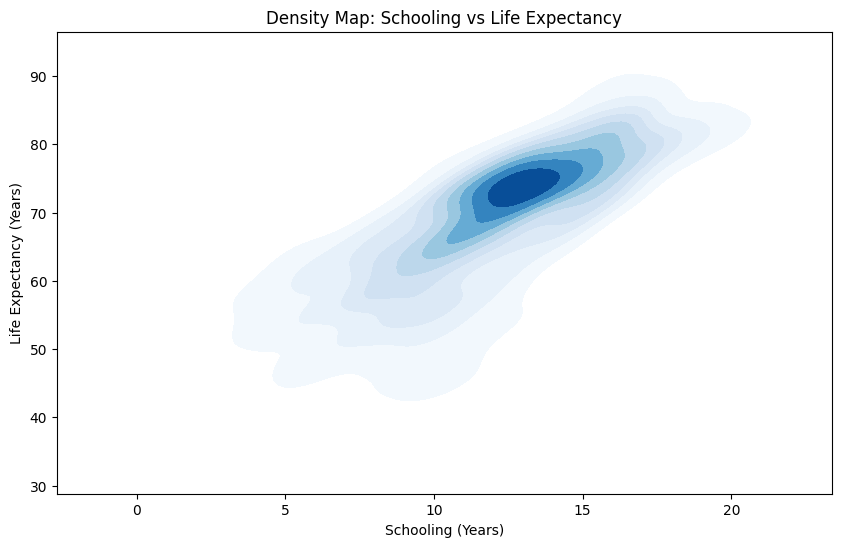

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.kdeplot(x=df['Schooling'], y=df['Life expectancy'], fill=True, cmap='Blues', thresh=0.05)

plt.title('Density Map: Schooling vs Life Expectancy')
plt.xlabel('Schooling (Years)')
plt.ylabel('Life Expectancy (Years)')
plt.show()

#### 2.1.4 Outlier Detection

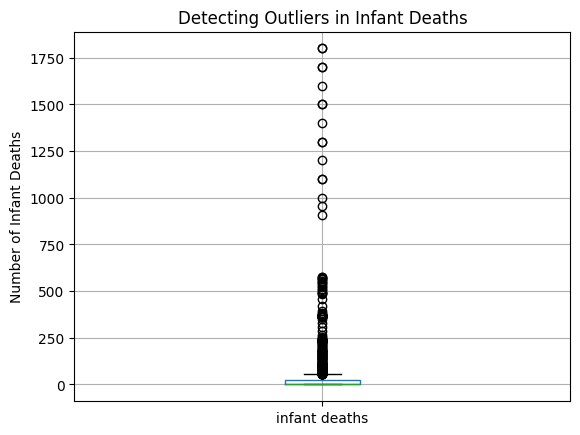

In [ ]:
df.boxplot(column='infant deaths')

plt.title('Detecting Outliers in Infant Deaths')
plt.ylabel('Number of Infant Deaths')
plt.show()

## Phase 3: Data Preparation

Now that I have understood the data, I need to prepare it before giving it to the models.

### Data preparation plan
1. Remove rows where the target variable (`Life expectancy`) is missing because the target should not be imputed.
2. Remove highly redundant predictors identified through correlation and VIF analysis: `infant deaths`, `percentage expenditure`, and `thinness 5-9 years`.
3. Keep `Country` out of the modelling features because it is a high-cardinality identifier rather than a numerical predictor.
4. Keep `Year` as a predictor because it may contain information about changes over time.
5. Separate the predictors (`X`) from the target (`y`).
6. Split the data into training and test sets before fitting preprocessing steps.
7. For numerical predictors, use median imputation and standardization. For the categorical `Status` variable, use most-frequent imputation followed by one-hot encoding. All preprocessing is fitted using the training data only.


### 3.1. Data Distribution

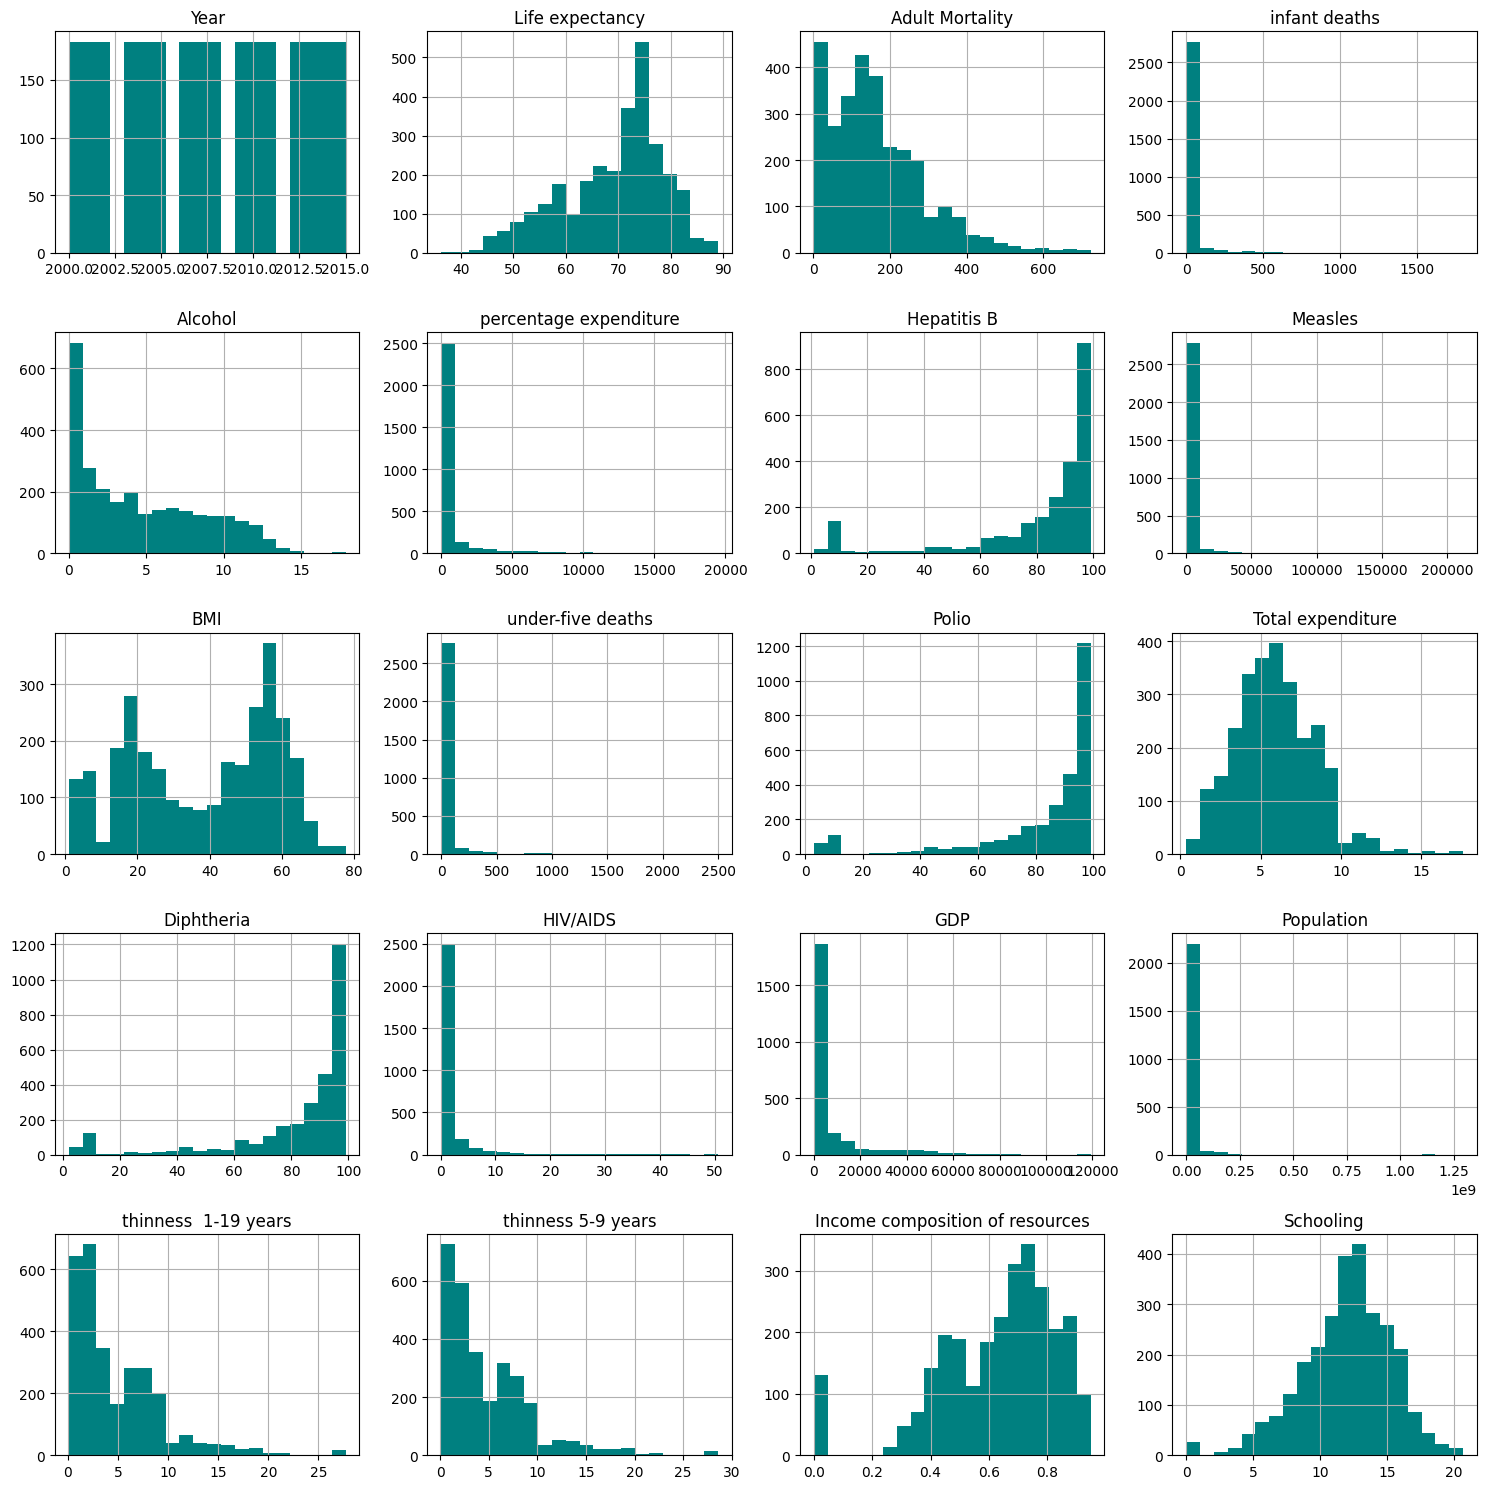

In [ ]:
df.hist(figsize=(15, 15), bins=20, color='teal')
plt.tight_layout()
plt.show()

### 3.2. Logical Slicing & Grouping

#### Boolean Indexing
separate developed country from developing country and calculate average of life expectancy of each.

In [ ]:
developed = df[df['Status'] == 'Developed']
developing = df[df['Status'] == 'Developing']

print("Developed Life Expectancy:", developed['Life expectancy'].mean())
print("Developing Life Expectancy:", developing['Life expectancy'].mean())

Developed Life Expectancy: 79.1978515625
Developing Life Expectancy: 67.11146523178807


#### Thresholding
making a decision boundry to find out do people live longer in a country where the economy performs above the global average?

In [ ]:
avg_gdp = df['GDP'].mean()

rich_countries = df[df['GDP'] > avg_gdp]
poor_countries = df[df['GDP'] <= avg_gdp]

print("Rich Countries Life Expectancy:", rich_countries['Life expectancy'].mean())
print("Poor Countries Life Expectancy:", poor_countries['Life expectancy'].mean())

Rich Countries Life Expectancy: 77.52740740740741
Poor Countries Life Expectancy: 67.10606683804627


#### AND/OR Logic
If a country has a low economic status (developing country) but invests in literacy and education (schooling), can it increase life expectancy?


In [ ]:
educated_developing = df[(df['Status'] == 'Developing') & (df['Schooling'] > 12)]

print("All Developing Life Expectancy:", developing['Life expectancy'].mean())
print("Educated Developing Life Expectancy:", educated_developing['Life expectancy'].mean())

All Developing Life Expectancy: 67.11146523178807
Educated Developing Life Expectancy: 73.47909002904163


#### grouping data

In [ ]:
grouped_data = df.groupby('Status').mean(numeric_only=True)

print("Hepatitis B Comparison:")
print(grouped_data['Hepatitis B'])

print("\nInfant Deaths Comparison:")
print(grouped_data['infant deaths'])


Hepatitis B Comparison:
Status
Developed     88.041298
Developing    79.781925
Name: Hepatitis B, dtype: float64

Infant Deaths Comparison:
Status
Developed      1.494141
Developing    36.534768
Name: infant deaths, dtype: float64


### 3.3.Correlation Heatmap

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()


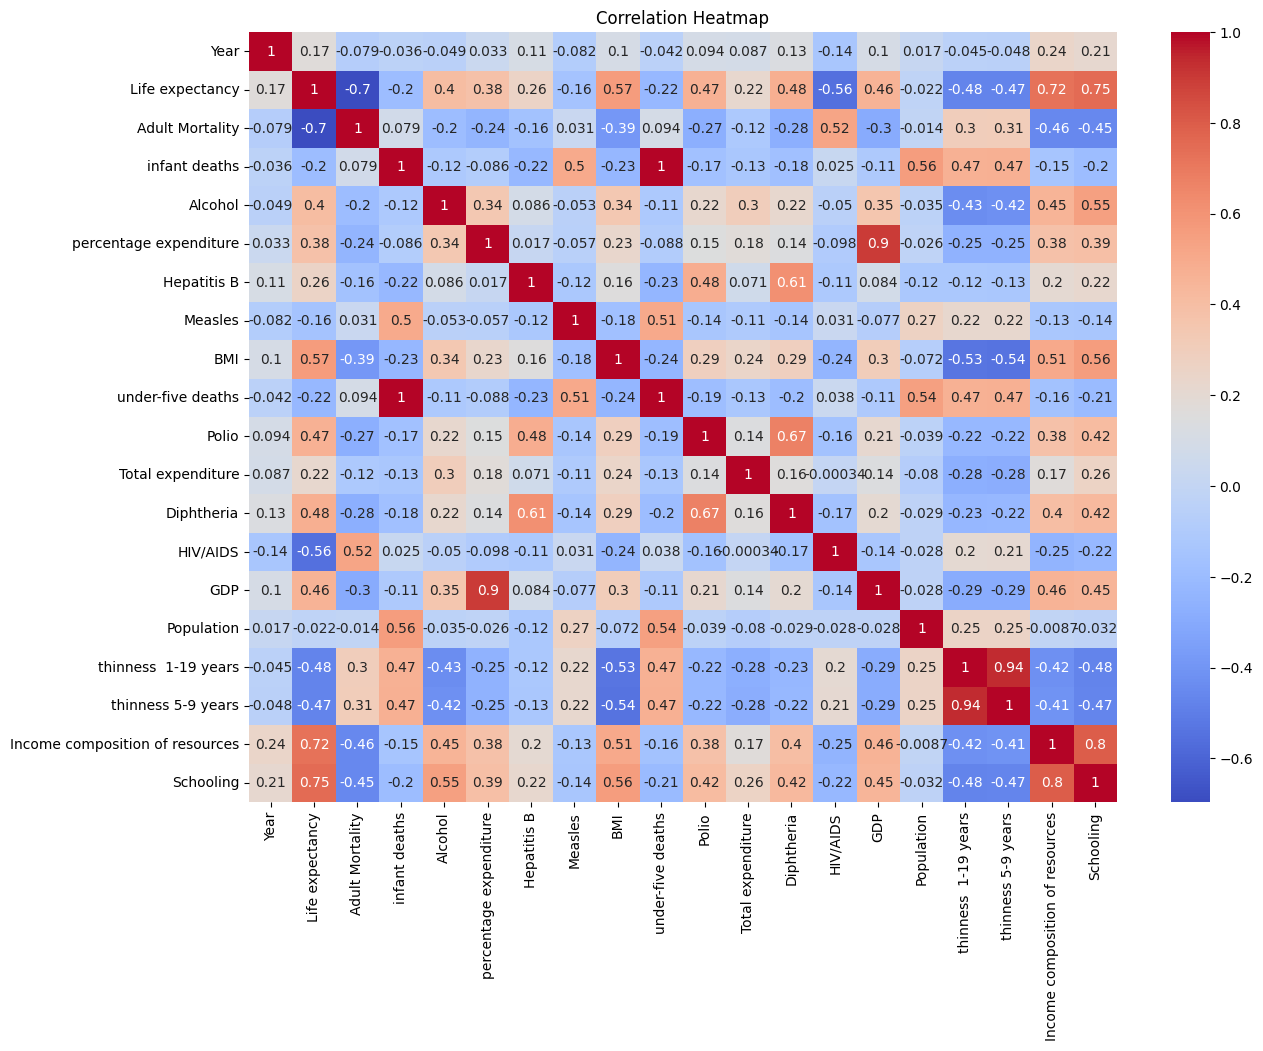

In [ ]:
import seaborn as sns

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm",annot = True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df[["infant deaths", "under-five deaths"]].corr()

,infant deaths,under-five deaths
infant deaths,1.000000,0.996628
under-five deaths,0.996628,1.000000


In [ ]:
df[["infant deaths", "under-five deaths"]].describe()

,infant deaths,under-five deaths
count,2928.000000,2928.000000
mean,30.407445,42.179303
std,118.114450,160.700547
min,0.000000,0.000000
25%,0.000000,0.000000
50%,3.000000,4.000000
75%,22.000000,28.000000
max,1800.000000,2500.000000


In [ ]:
df[["infant deaths", "under-five deaths"]].head(20)

,infant deaths,under-five deaths
0,62,83
1,64,86
2,66,89
3,69,93
4,71,97
5,74,102
6,77,106
7,80,110
8,82,113
9,84,116


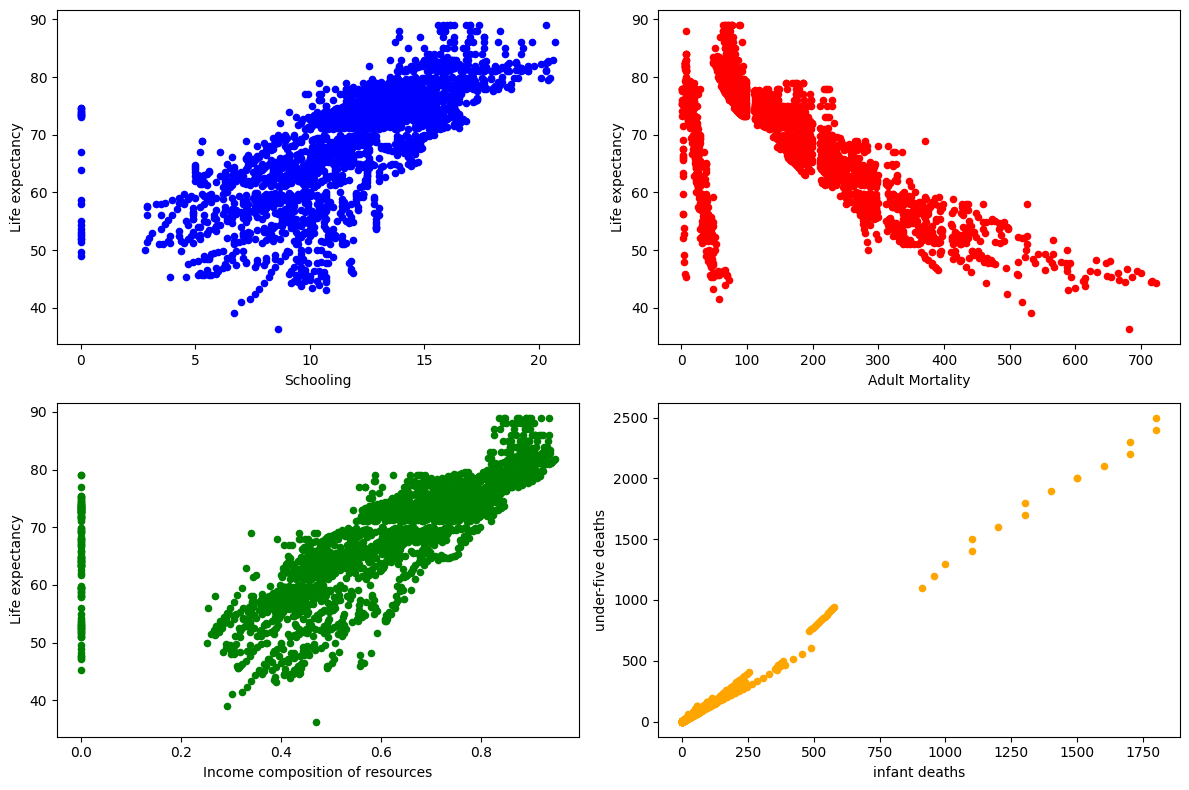

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df.plot.scatter(x='Schooling', y='Life expectancy', ax=axes[0,0], color='blue')
df.plot.scatter(x='Adult Mortality', y='Life expectancy', ax=axes[0,1], color='red')
df.plot.scatter(x='Income composition of resources', y='Life expectancy', ax=axes[1,0], color='green')
df.plot.scatter(x='infant deaths', y='under-five deaths', ax=axes[1,1], color='orange')

plt.tight_layout()
plt.show()

### 3.3. Correlation Matrix

Now I want to see which features have the strongest mathematical relationship with Life Expectancy. A correlation matrix calculates a score between -1 and 1 for every pair of columns.

* **Close to 1:** Strong positive relationship (e.g., as Schooling goes up, Life Expectancy goes up).
* **Close to -1:** Strong negative relationship (e.g., as Adult Mortality goes up, Life Expectancy goes down).

I will calculate the matrix and sort the results specifically for my target variable.

In [ ]:
correlation_matrix = df.corr(numeric_only=True)

target_correlation = correlation_matrix['Life expectancy'].sort_values(ascending=False)
print(target_correlation)

Life expectancy                    1.000000
Schooling                          0.751975
Income composition of resources    0.724776
BMI                                0.567694
Diphtheria                         0.479495
Polio                              0.465556
GDP                                0.461455
Alcohol                            0.404877
percentage expenditure             0.381864
Hepatitis B                        0.256762
Total expenditure                  0.218086
Year                               0.170033
Population                        -0.021538
Measles                           -0.157586
infant deaths                     -0.196557
under-five deaths                 -0.222529
thinness 5-9 years                -0.471584
thinness  1-19 years              -0.477183
HIV/AIDS                          -0.556556
Adult Mortality                   -0.696359
Name: Life expectancy, dtype: float64


### 3.4.Outlier Detection
Linear regression is highly sensitive to outliers because it minimizes squared errors. A single extreme value can tilt the entire regression line.
Earlier, I saw outliers visually using a Boxplot. Now, I will use the mathematical Interquartile Range (IQR) method to find and isolate these extreme rows in the 'infant deaths' column.

In [ ]:
q1 = df['infant deaths'].quantile(0.25)
q3 = df['infant deaths'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

outliers = df[(df['infant deaths'] < lower_bound) | (df['infant deaths'] > upper_bound)]

print(len(outliers))
print(outliers[['Status', 'infant deaths']].head(10))

315
       Status  infant deaths
0  Developing             62
1  Developing             64
2  Developing             66
3  Developing             69
4  Developing             71
5  Developing             74
6  Developing             77
7  Developing             80
8  Developing             82
9  Developing             84


#### Visualizing Quartiles (Q1, Q2, Q3)

To truly understand what a Boxplot does mathematically, I need to see the quartiles slicing through the data distribution. Q1 cuts the bottom 25%, Q2 (Median) cuts the data in half, and Q3 marks the top 25%. The area between Q1 and Q3 is the Interquartile Range (IQR) which holds the core 50% of the dataset.

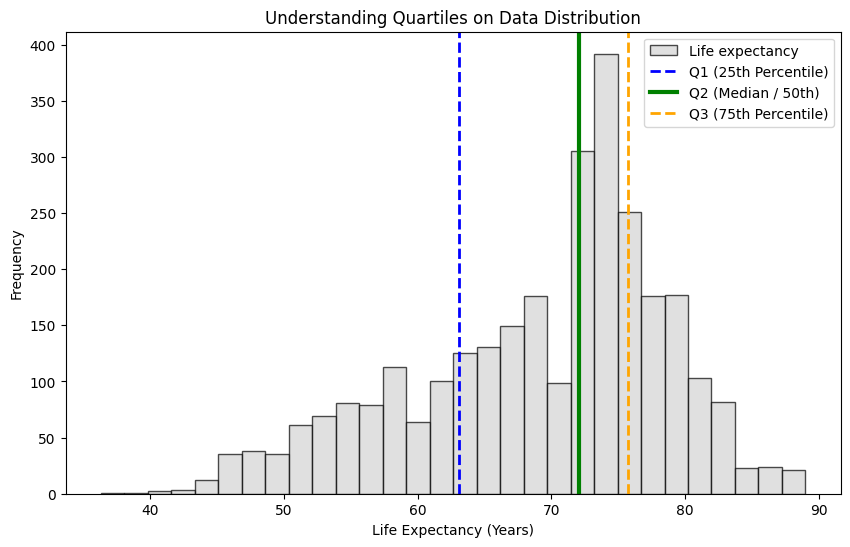

In [ ]:
plt.figure(figsize=(10, 6))

df['Life expectancy'].plot(kind='hist', bins=30, color='lightgray', edgecolor='black', alpha=0.7)

q1 = df['Life expectancy'].quantile(0.25)
q2 = df['Life expectancy'].median()
q3 = df['Life expectancy'].quantile(0.75)

plt.axvline(x=q1, color='blue', linestyle='--', linewidth=2, label='Q1 (25th Percentile)')
plt.axvline(x=q2, color='green', linestyle='-', linewidth=3, label='Q2 (Median / 50th)')
plt.axvline(x=q3, color='orange', linestyle='--', linewidth=2, label='Q3 (75th Percentile)')

plt.title('Understanding Quartiles on Data Distribution')
plt.xlabel('Life Expectancy (Years)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### 3.5 Noise Detection

Noise refers to meaningless, corrupted, or impossible data caused by measurement errors, system bugs, or human typos. Unlike outliers (which are extreme but real), noise is fundamentally false. I will define real-world logical boundaries (e.g., life expectancy cannot be less than 10 or greater than 120, and deaths cannot be negative) to detect and count any noisy records in the dataset.

In [ ]:
noise_life = df[(df['Life expectancy'] < 10) | (df['Life expectancy'] > 120)]

noise_infant = df[df['infant deaths'] < 0]

print("Invalid Life Expectancy Records:", len(noise_life))
print("Invalid Infant Deaths Records:", len(noise_infant))

Invalid Life Expectancy Records: 0
Invalid Infant Deaths Records: 0


### 3.6 Data Inconsistency

Inconsistency occurs when two or more columns logically contradict each other. In this dataset, the number of "infant deaths" (under 1 year old) cannot logically exceed the number of "under-five deaths" (under 5 years old), because the latter group includes the former. I will use Pandas to filter and check if there are any contradictory rows in our data.

In [ ]:
inconsistent_data = df[df['infant deaths'] > df['under-five deaths']]

print("Number of inconsistent rows:", len(inconsistent_data))

print(inconsistent_data[['Country', 'Year', 'infant deaths', 'under-five deaths']].head())

Number of inconsistent rows: 0
Empty DataFrame
Columns: [Country, Year, infant deaths, under-five deaths]
Index: []


In [ ]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

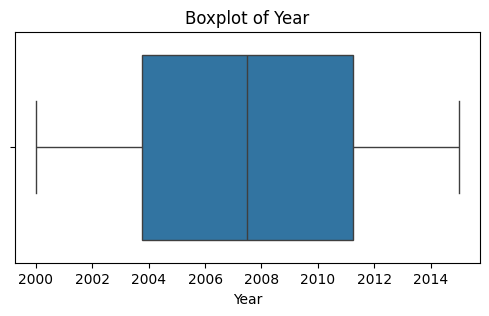

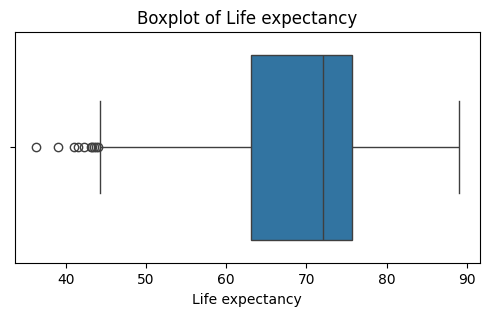

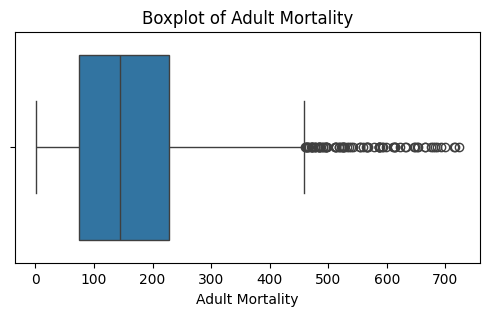

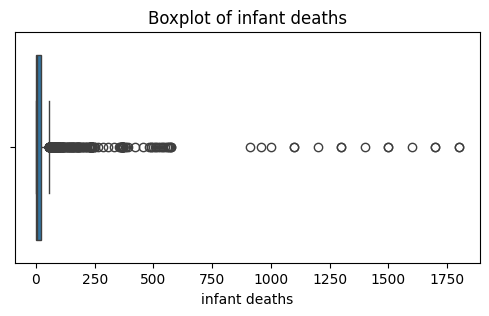

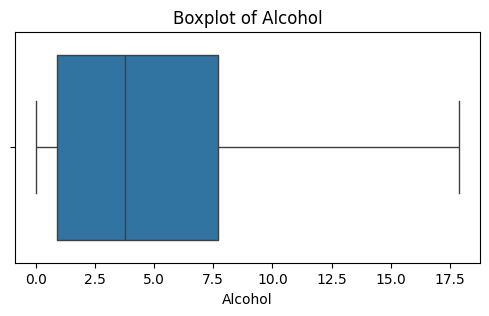

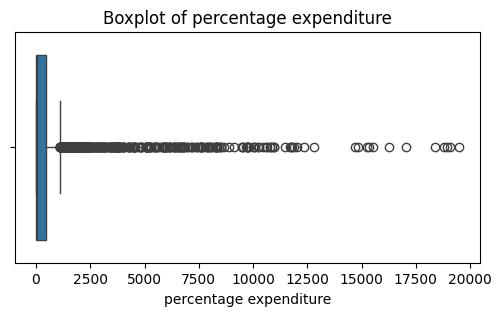

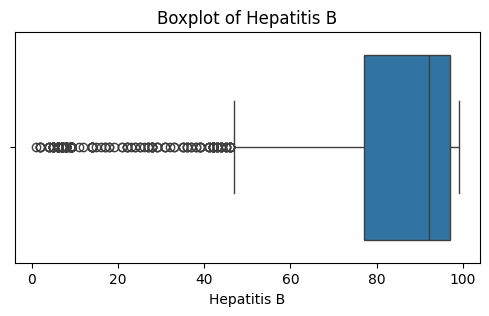

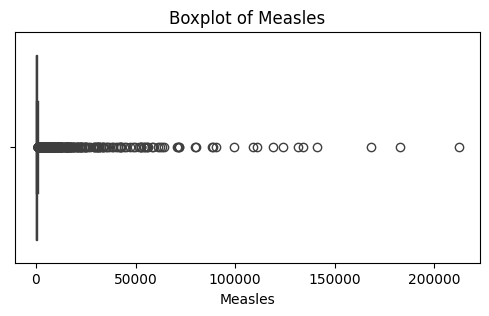

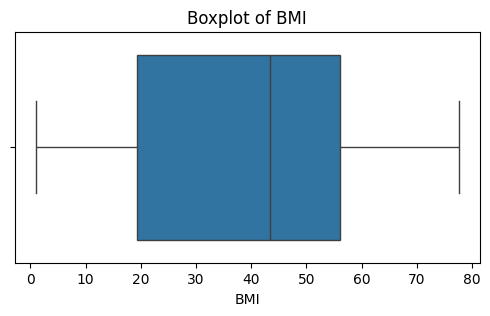

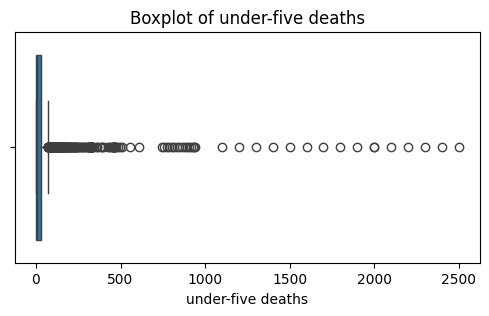

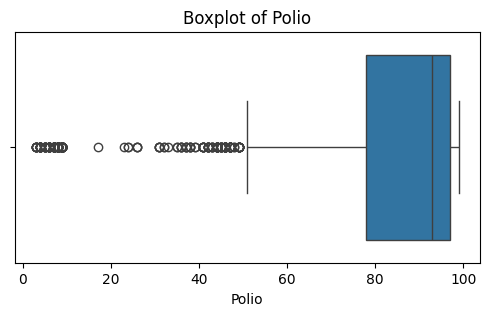

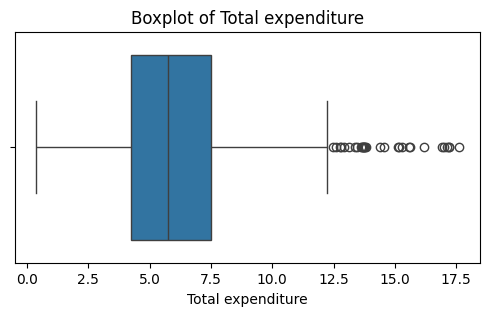

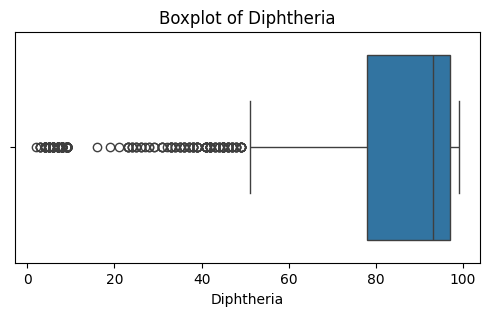

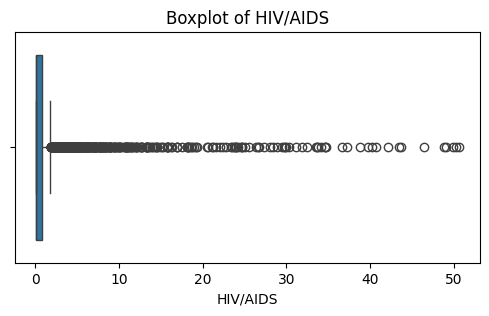

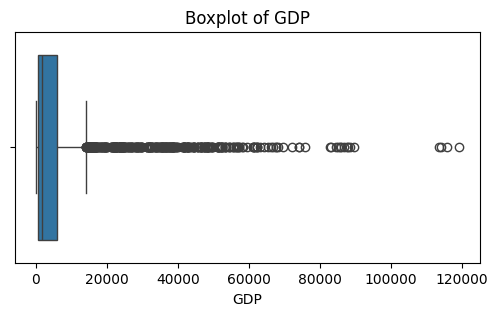

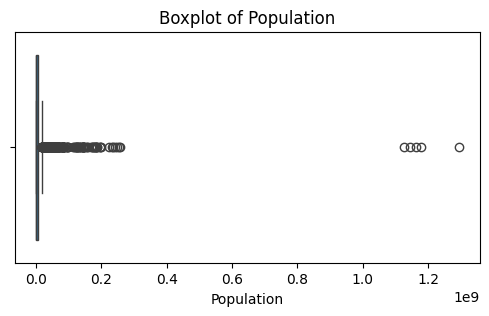

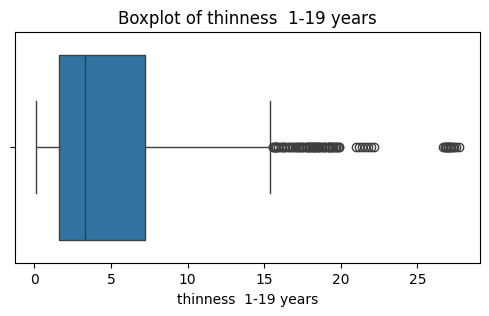

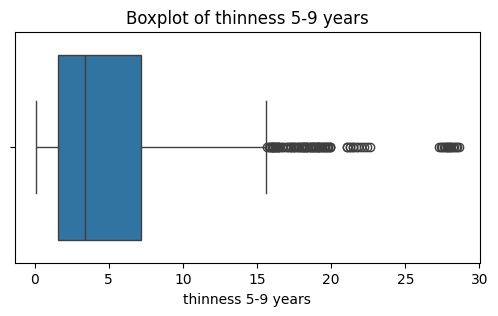

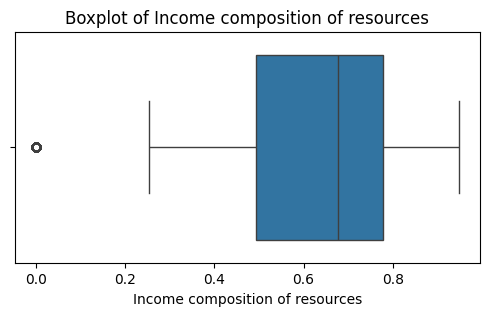

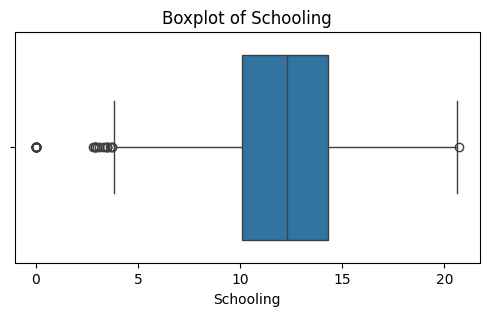

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
outlier_counts = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_counts[col] = count

outlier_counts

{'Year': np.int64(0),
 'Life expectancy': np.int64(10),
 'Adult Mortality': np.int64(82),
 'infant deaths': np.int64(315),
 'Alcohol': np.int64(0),
 'percentage expenditure': np.int64(388),
 'Hepatitis B': np.int64(252),
 'Measles': np.int64(542),
 'BMI': np.int64(0),
 'under-five deaths': np.int64(394),
 'Polio': np.int64(278),
 'Total expenditure': np.int64(30),
 'Diphtheria': np.int64(297),
 'HIV/AIDS': np.int64(542),
 'GDP': np.int64(363),
 'Population': np.int64(294),
 'thinness  1-19 years': np.int64(89),
 'thinness 5-9 years': np.int64(97),
 'Income composition of resources': np.int64(130),
 'Schooling': np.int64(42)}

In [ ]:
df.nlargest(10, "Population")[
    ["Country", "Year", "Population", "Life expectancy"]
]

,Country,Year,Population,Life expectancy
1187,India,2014,1.293859e+09,68.0
1194,India,2007,1.179681e+09,65.2
1195,India,2006,1.161978e+09,64.8
1196,India,2005,1.144119e+09,64.4
1197,India,2004,1.126136e+09,64.0
1202,Indonesia,2015,2.581621e+08,69.1
1203,Indonesia,2014,2.551311e+08,68.9
1205,Indonesia,2012,2.488832e+08,68.5
1207,Indonesia,2010,2.425241e+08,68.1
1209,Indonesia,2008,2.361593e+08,67.7


In [ ]:
df.nlargest(10, "GDP")[
    ["Country", "Year", "GDP", "Life expectancy"]
]

,Country,Year,GDP,Life expectancy
1539,Luxembourg,2014,119172.74180,81.7
1542,Luxembourg,2011,115761.57700,88.0
1545,Luxembourg,2008,114293.84330,80.0
1540,Luxembourg,2013,113751.85000,81.4
1547,Luxembourg,2006,89739.71170,79.4
2074,Qatar,2012,88564.82298,77.8
2525,Switzerland,2011,87998.44468,82.6
1915,Norway,2010,87646.75346,81.0
2072,Qatar,2014,86852.71190,78.1
2075,Qatar,2011,85948.74600,77.5


In [ ]:
df.nlargest(10, "HIV/AIDS")[
    ["Country", "Year", "HIV/AIDS", "Life expectancy"]
]

,Country,Year,HIV/AIDS,Life expectancy
2501,Swaziland,2003,50.6,45.9
2500,Swaziland,2004,50.3,45.6
2502,Swaziland,2002,49.9,46.4
2499,Swaziland,2005,49.1,46.0
2503,Swaziland,2001,48.8,47.1
2504,Swaziland,2000,46.4,48.4
2498,Swaziland,2006,43.7,47.8
2937,Zimbabwe,2000,43.5,46.0
2936,Zimbabwe,2001,42.1,45.3
2497,Swaziland,2007,40.7,50.0


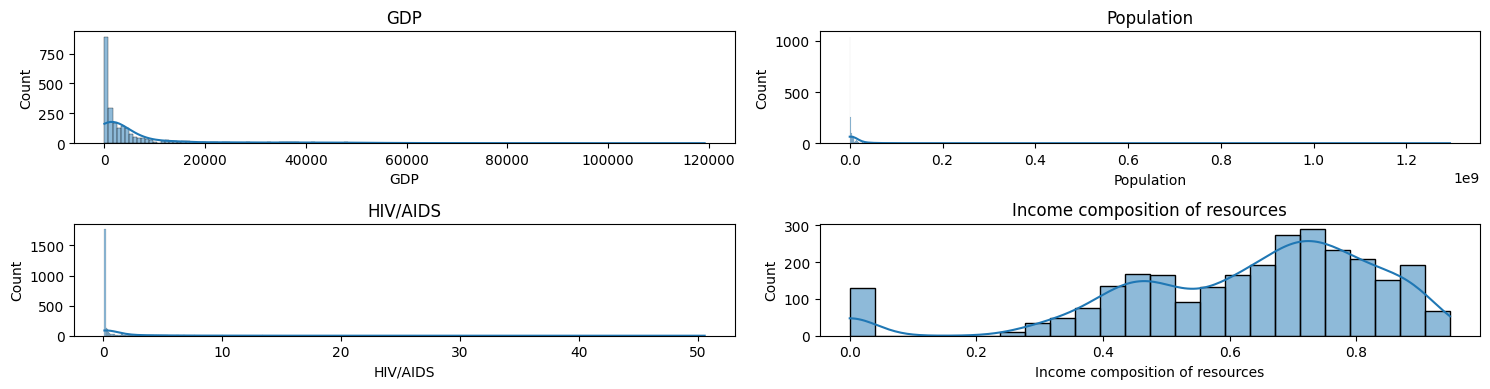

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 4))

sns.histplot(df["GDP"], kde=True, ax=axes[0][0])
axes[0][0].set_title("GDP")

sns.histplot(df["Population"], kde=True, ax=axes[0][1])
axes[0][1].set_title("Population")

sns.histplot(df["HIV/AIDS"], kde=True, ax=axes[1][0])
axes[1][0].set_title("HIV/AIDS")

sns.histplot(df["Income composition of resources"], kde=True, ax=axes[1][1])
axes[1][1].set_title("Income composition of resources")

plt.tight_layout()
plt.show()

In [ ]:
df[df["Income composition of resources"] < 0.2][
    ["Country", "Year", "Income composition of resources", "Life expectancy"]
].sort_values("Income composition of resources")

,Country,Year,Income composition of resources,Life expectancy
74,Antigua and Barbuda,2005,0.0,74.6
75,Antigua and Barbuda,2004,0.0,74.4
76,Antigua and Barbuda,2003,0.0,74.2
77,Antigua and Barbuda,2002,0.0,74.0
78,Antigua and Barbuda,2001,0.0,73.8
...,...,...,...,...
2853,Vanuatu,2004,0.0,69.6
2854,Vanuatu,2003,0.0,69.4
2855,Vanuatu,2002,0.0,69.3
2856,Vanuatu,2001,0.0,69.1


"Income composition of resources showed a non-normal, somewhat multimodal distribution with a small number of extreme low values. These observations were retained because no evidence of invalid or erroneous values was found; they may represent genuine differences in socioeconomic conditions across countries."

 the plots prove that these features are right skewed which is quite obvious since some countries have large population,GDP and correspondingly higher HIV/AIDS cases these are not erroneous data

infant deaths,death under 5 years and measles outlier anslysis

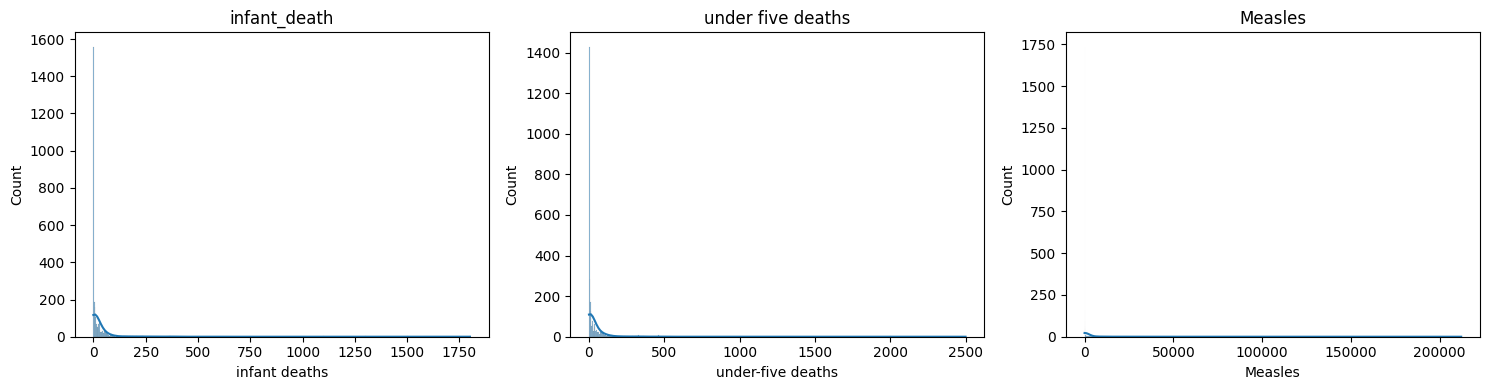

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["infant deaths"], kde=True, ax=axes[0])
axes[0].set_title("infant_death")

sns.histplot(df["under-five deaths"], kde=True, ax=axes[1])
axes[1].set_title("under five deaths")

sns.histplot(df["Measles"], kde=True, ax=axes[2])
axes[2].set_title("Measles")

plt.tight_layout()
plt.show()

In [ ]:
df.nlargest(10, "Measles")[
    ["Country", "Year", "Measles", "Life expectancy"]
]

,Country,Year,Measles,Life expectancy
1908,Nigeria,2000,212183,47.1
731,Democratic Republic of the Congo,2005,182485,54.3
1907,Nigeria,2001,168107,47.4
1905,Nigeria,2003,141258,48.1
725,Democratic Republic of the Congo,2011,133802,57.9
567,China,2008,131441,74.5
570,China,2005,124219,73.9
1575,Malawi,2010,118712,52.9
1903,Nigeria,2005,110927,49.2
568,China,2007,109023,74.4


These values are not noise its real world data which simply cant be removed by saying erroneous

**Conclusion of outlier analysis **:

"The IQR method identified several extreme observations in variables such as GDP, Population, Measles, HIV/AIDS, infant deaths and under-five deaths. However, these variables are naturally skewed and represent genuine differences among countries. Therefore, the observations were not removed solely based on the IQR criterion. Logical and consistency checks were performed to identify potentially erroneous records. No invalid observations were identified through these checks. Appropriate transformations of highly skewed predictors will be evaluated during modeling."

## Phase 4: Modeling
### 4.1. Defining Features (X) and Target (y)

The machine learning model needs to separate the independent variables (Features) from the dependent variable (Target).
* **X (Features):** The data the model will use to learn (e.g., Schooling, GDP, Adult Mortality).
* **y (Target):** The answer the model is trying to predict (Life expectancy).

Country is categorical with many different countries. One-hot encoding it would create a large number of dummy variables

In [ ]:
X = df.drop(columns=["Life expectancy", "Country"])
y = df["Life expectancy"]

### 4.2. Train-Test Split

If we train the model on all the data, it might just memorize the answers (Overfitting). To truly test if the model has learned the underlying structural mechanics, we must hide 20% of the data. The model will learn from the 80% (Training Set) and take an exam on the unseen 20% (Testing Set).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### 4.3. Feature Scaling (Standardization)  and Imputation( fillling NAN values)

Machine learning algorithms can be biased if the numeric ranges of features are vastly different. `StandardScaler` standardizes features by removing the mean and scaling to unit variance (mean = 0, standard deviation = 1), ensuring the math engine treats all features equally.

In [ ]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

In [ ]:
X_train.columns


Index(['Year', 'Status', 'Adult Mortality', 'infant deaths', 'Alcohol',
       'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI',
       'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria',
       'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer,PowerTransformer
from sklearn.impute import SimpleImputer
import numpy as np

# Right-skewed numerical columns
right_skewed_cols = ['Adult Mortality', 'percentage expenditure', 'infant deaths','under-five deaths','percentage expenditure','Measles','GDP','Population','Total expenditure','HIV/AIDS','thinness  1-19 years','thinness 5-9 years']

# Other numerical columns
other_num_cols = ['Year','Alcohol','BMI','Income composition of resources']

# Left-skewed numerical columns
left_skewed_cols = ['Hepatitis B','Polio','Diphtheria','Schooling']

# cat cols
cat_cols = ['Status']

# Pipeline for right-skewed columns
right_skew_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

# Pipeline for other numerical columns
other_num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline for left-skewed columns
left_skew_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", PowerTransformer()),
    ("scaler", StandardScaler())
])





# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# Combine
preprocessor = ColumnTransformer([
    ("right_skew", right_skew_pipeline, right_skewed_cols),
    ("left_skew", left_skew_pipeline, left_skewed_cols),
    ("other_num", other_num_pipeline, other_num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

### 4.4. Building and Training the Model

I will instantiate the structural Linear Regression algorithm. The `.fit()` function is the actual learning process where the algorithm calculates the optimal weights (coefficients) to minimize the error between predictions and reality.

In [ ]:
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} Years")
print(f"R-squared Score (R2): {r2:.2f}")

Mean Absolute Error (MAE): 2.79 Years
R-squared Score (R2): 0.85


Checking for the normality of residuals for validity of linear regression model

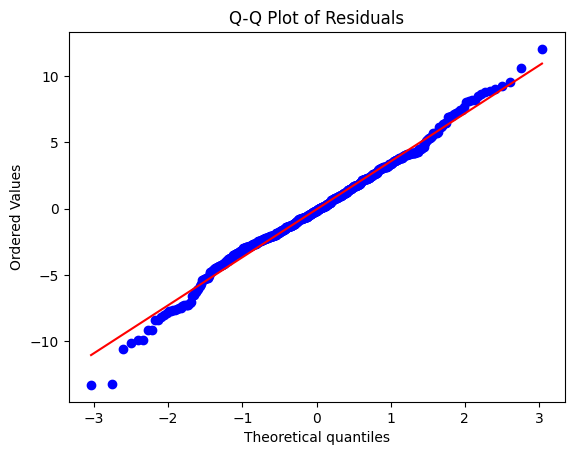

In [ ]:
residuals = y_test - y_pred
import matplotlib.pyplot as plt
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

This suggests that the residuals are approximately normal in the central region but have heavier/non-normal tails.

/tmp/ipykernel_1532/2564465002.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde = True,hist = False)


<Axes: xlabel='Life expectancy', ylabel='Density'>

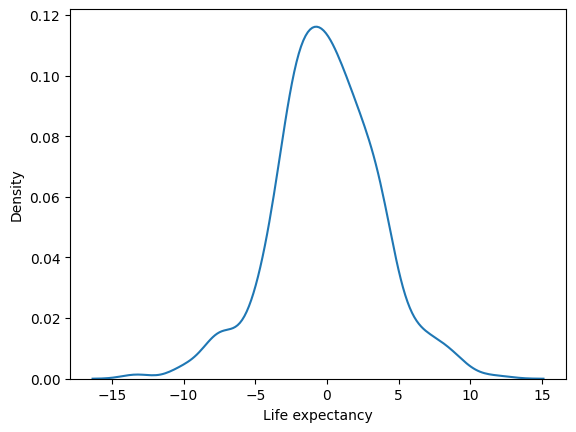

In [ ]:
sns.distplot(residuals,kde = True,hist = False)

density plot is roughly bell-shaped and centered around 0, but it is not perfectly symmetric. There is a noticeably longer left tail.

the residuals are not perfectly normal, but the departure is mainly in the tails rather than throughout the distribution.

Shapiro - Wilk test

In [ ]:
from scipy.stats import shapiro

stat, p_value = shapiro(residuals)

print("Shapiro-Wilk statistic:", stat)
print("p-value:", p_value)

Shapiro-Wilk statistic: 0.9908335256563889
p-value: 0.0010599634191152218


since p-value < 0.978 we reject the null hyptohesis and conclude that we have significant evidence that residuals are not normally distributed

Normality of residuals: The Q-Q plot shows that the residuals approximately follow a straight line in the central region, with noticeable deviations in the tails. The Shapiro-Wilk test gives a p-value less than 0.05, indicating a statistically significant departure from normality. Therefore, the residuals cannot be considered perfectly normally distributed, with the main deviation occurring in the tails.

 # Auto correlation of residuals

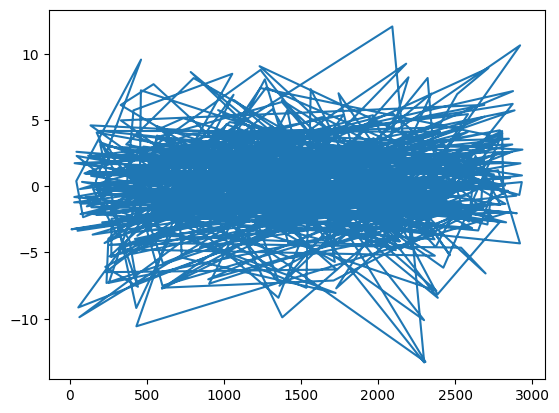

In [ ]:
plt.plot(residuals)

# Homoscedasticity

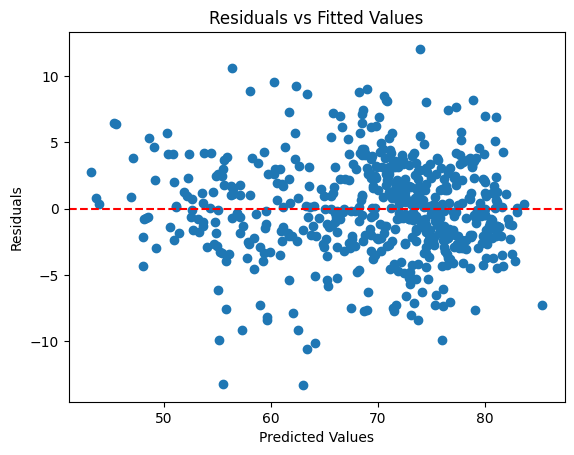

In [ ]:
plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

As from the above figure we can that we cant find any pattern of data between the residuals and Y_pred , therefore it is homoscedastic

# Multicollinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = X_train.select_dtypes(include="number").copy()

# Remove rows containing missing values
X_vif = X_vif.dropna()

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

print(vif)

                            Feature       VIF
15                        Schooling  3.457649
14  Income composition of resources  2.952463
6                 under-five deaths  2.269086
9                        Diphtheria  2.081300
13             thinness  1-19 years  1.950290
2                           Alcohol  1.929228
5                               BMI  1.783773
1                   Adult Mortality  1.703187
7                             Polio  1.700415
3                       Hepatitis B  1.683100
12                       Population  1.548521
10                         HIV/AIDS  1.459467
11                              GDP  1.407522
4                           Measles  1.381667
0                              Year  1.158467
8                 Total expenditure  1.108943


This suggests that some columns are highly correlated with others
e.g. infant deaths and under-five deaths are  highly correlated

we will try to retrain the model after removing some of the columns which are highly correlated with other

In [ ]:
df = df.drop(columns=[
    "infant deaths",
    "percentage expenditure",
    "thinness 5-9 years"
])

X = df.drop(columns=["Life expectancy", "Country"])
y = df["Life expectancy"]


KeyError: "['infant deaths', 'percentage expenditure', 'thinness 5-9 years'] not found in axis"

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

calculate VIF again

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = X_train.select_dtypes(include="number").copy()

# Handle missing values
X_vif = X_vif.fillna(X_vif.median())

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

print(vif)

                            Feature       VIF
15                        Schooling  3.352554
14  Income composition of resources  2.989397
9                        Diphtheria  2.092376
6                 under-five deaths  1.973007
13             thinness  1-19 years  1.938398
7                             Polio  1.893549
5                               BMI  1.713122
1                   Adult Mortality  1.680652
2                           Alcohol  1.589892
10                         HIV/AIDS  1.397185
4                           Measles  1.345444
12                       Population  1.315256
11                              GDP  1.301896
3                       Hepatitis B  1.299454
8                 Total expenditure  1.159990
0                              Year  1.130789


Now all VIF are less than 5 so we have solved the problem of multicollinearity

Multicollinearity: Multicollinearity was assessed using the Variance Inflation Factor (VIF). Initially, very high VIF values were observed for infant deaths, under-five deaths, GDP, percentage expenditure, and the two thinness variables. Based on the strong redundancy among these predictors, infant deaths, percentage expenditure, and thinness 5-9 years were removed. After this adjustment, all remaining predictors had VIF values below 5, with the maximum VIF being 3.35 for Schooling. Therefore, severe multicollinearity was no longer present in the revised predictor set.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer,PowerTransformer
from sklearn.impute import SimpleImputer
import numpy as np

# Right-skewed numerical columns
right_skewed_cols = ['Adult Mortality','under-five deaths','Measles','GDP','Population','Total expenditure','HIV/AIDS','thinness  1-19 years']

# Other numerical columns
other_num_cols = ['Year','Alcohol','BMI','Income composition of resources']

# Left-skewed numerical columns
left_skewed_cols = ['Hepatitis B','Polio','Diphtheria','Schooling']

# cat cols
cat_cols = ['Status']

# Pipeline for right-skewed columns
right_skew_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

# Pipeline for other numerical columns
other_num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline for left-skewed columns
left_skew_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", PowerTransformer()),
    ("scaler", StandardScaler())
])





# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# Combine
preprocessor = ColumnTransformer([
    ("right_skew", right_skew_pipeline, right_skewed_cols),
    ("left_skew", left_skew_pipeline, left_skewed_cols),
    ("other_num", other_num_pipeline, other_num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [ ]:
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])


model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

# Number of observations
n = len(y_test)

# Number of predictors after preprocessing
p = model.named_steps["preprocessor"].transform(X_test).shape[1]

# Adjusted R²
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE: {mae:.2f} years")
print(f"RMSE: {rmse:.2f} years")
print(f"R²: {r2:.2f}")
print(f"Adjusted R²: {adjusted_r2:.2f}")

MAE: 2.83 years
RMSE: 3.68 years
R²: 0.84
Adjusted R²: 0.84


# Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

r2_ridge = r2_score(y_test, y_pred_ridge)

# Number of observations
n = len(y_test)

# Number of predictors after preprocessing
p = ridge_model.named_steps["preprocessor"].transform(X_test).shape[1]

# Adjusted R²
adjusted_r2_ridge = 1 - (1 - r2_ridge) * (n - 1) / (n - p - 1)

print(f"Ridge MAE: {mae_ridge:.2f} years")
print(f"Ridge RMSE: {rmse_ridge:.2f} years")
print(f"Ridge R²: {r2_ridge:.2f}")
print(f"Ridge Adjusted R²: {adjusted_r2_ridge:.2f}")

Ridge MAE: 2.83 years
Ridge RMSE: 3.68 years
Ridge R²: 0.84
Ridge Adjusted R²: 0.84


# Lasso regression

In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Lasso(alpha=0.01, max_iter=10000))
])

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

r2_lasso = r2_score(y_test, y_pred_lasso)

# Number of observations
n = len(y_test)

# Number of predictors after preprocessing
p = lasso_model.named_steps["preprocessor"].transform(X_test).shape[1]

# Adjusted R²
adjusted_r2_lasso = 1 - (1 - r2_lasso) * (n - 1) / (n - p - 1)

print(f"Lasso MAE: {mae_lasso:.2f} years")
print(f"Lasso RMSE: {rmse_lasso:.2f} years")
print(f"Lasso R²: {r2_lasso:.2f}")
print(f"Lasso Adjusted R²: {adjusted_r2_lasso:.2f}")

Lasso MAE: 2.84 years
Lasso RMSE: 3.68 years
Lasso R²: 0.84
Lasso Adjusted R²: 0.84


“Lasso regression was evaluated with different values of the regularization parameter \(\alpha\). The model showed very similar performance across the tested values, with MAE, RMSE and \(R^2\) remaining approximately unchanged. Therefore, changing the strength of L1 regularization did not provide a meaningful improvement in predictive performance.”

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=42,max_depth = 10))
])

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [ ]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree MAE: {mae_dt:.2f} years")
print(f"Decision Tree RMSE: {rmse_dt:.2f} years")
print(f"Decision Tree R²: {r2_dt:.2f}")


Decision Tree MAE: 1.59 years
Decision Tree RMSE: 2.54 years
Decision Tree R²: 0.93


Is this overfitting ?

In [ ]:
y_train_pred_dt = dt_model.predict(X_train)

print("Training R²:", r2_score(y_train, y_train_pred_dt))
print("Test R²:", r2_score(y_test, y_pred_dt))

print("Training MAE:", mean_absolute_error(y_train, y_train_pred_dt))
print("Test MAE:", mean_absolute_error(y_test, y_pred_dt))

Training R²: 0.9856134593573511
Test R²: 0.9252944779285948
Training MAE: 0.6803970461062986
Test MAE: 1.5865913541102585


### Overfitting in the unrestricted Decision Tree

The unrestricted Decision Tree showed signs of overfitting: its training R² was 1.00 and its training MAE was essentially zero, while its test performance was lower. This means the tree was able to fit the training observations almost perfectly but did not reproduce that performance on unseen observations.

To control model complexity, I therefore tune `max_depth` rather than using a completely unrestricted tree.


Tuning max_depth to control overfitting(reducing)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

depths = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]

for depth in depths:
    dt = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", DecisionTreeRegressor(
            max_depth=depth,
            random_state=42
        ))
    ])

    dt.fit(X_train, y_train)

    pred = dt.predict(X_test)

    print(
        f"Depth={depth:2d} | "
        f"MAE={mean_absolute_error(y_test, pred):.2f} | "
        f"RMSE={np.sqrt(mean_squared_error(y_test, pred)):.2f} | "
        f"R²={r2_score(y_test, pred):.3f}"
    )

Depth= 2 | MAE=3.82 | RMSE=4.86 | R²=0.726
Depth= 3 | MAE=2.90 | RMSE=3.91 | R²=0.823
Depth= 4 | MAE=2.59 | RMSE=3.48 | R²=0.860
Depth= 5 | MAE=2.18 | RMSE=2.96 | R²=0.899
Depth= 6 | MAE=1.88 | RMSE=2.65 | R²=0.919
Depth= 8 | MAE=1.70 | RMSE=2.50 | R²=0.928
Depth=10 | MAE=1.59 | RMSE=2.54 | R²=0.925
Depth=12 | MAE=1.58 | RMSE=2.59 | R²=0.922
Depth=15 | MAE=1.56 | RMSE=2.63 | R²=0.920
Depth=20 | MAE=1.54 | RMSE=2.67 | R²=0.918


### Selecting `max_depth`

The initial experiment showed that Decision Tree performance improved substantially as `max_depth` increased up to around 8–10, after which performance became fairly stable. This was useful for understanding the bias-variance trade-off.

For the final model, however, `max_depth` and `min_samples_leaf` are selected using **5-fold cross-validation on the training data** in the hyperparameter-tuning section below. This avoids using the test set to choose the final tree complexity.


## Decision Tree Result

The unrestricted Decision Tree showed clear signs of overfitting, with a training R² of 1.00 and training MAE approximately equal to zero. After evaluating several values of `max_depth`, a depth of 10 was selected.

The selected Decision Tree achieved approximately:

- **MAE:** 1.56 years
- **RMSE:** 2.52 years
- **R²:** 0.926

The model explains approximately 92.6% of the variation in life expectancy in the test set. The MAE indicates that the predictions are, on average, about 1.56 years away from the observed life expectancy.


### 4.7. Manual Prediction on Unseen Data

A completely new country-year observation can be passed directly to the trained Decision Tree pipeline. The new observation must contain the same predictor columns used by the final model. Because the preprocessing steps are inside the pipeline, the same imputation, scaling, and categorical encoding learned from the training data are automatically applied.

No separate manual log transformation or manual standardization is required because neither is part of the current preprocessing pipeline.


In [ ]:
new_data = pd.DataFrame({
    "Year": [2015],
    "Status": ["Developing"],
    "Adult Mortality": [150],
    "Alcohol": [4.5],
    "Hepatitis B": [80],
    "Measles": [10],
    "BMI": [25.5],
    "under-five deaths": [30],
    "Polio": [85],
    "Total expenditure": [6.0],
    "Diphtheria": [85],
    "HIV/AIDS": [0.2],
    "GDP": [5000],
    "Population": [5000000],
    "thinness  1-19 years": [4.0],
    "Income composition of resources": [0.65],
    "Schooling": [12.5]
})

Predict life expectancy

In [ ]:
predicted_life_expectancy = dt_model.predict(new_data)

print(f"Predicted Life Expectancy: {predicted_life_expectancy[0]:.2f} years")

Predicted Life Expectancy: 72.40 years


Manual Prediction on Unseen Data: A new country-year observation was created using values for the predictor variables. The trained Decision Tree pipeline was then used to predict its life expectancy. Since the preprocessing steps are included within the pipeline, the same transformations learned from the training data were automatically applied to the new observation before prediction.

### 4.8. Visualizing Model Performance (Actual vs Predicted)

MAE, RMSE and R² provide numerical measures of predictive performance. An **Actual vs Predicted scatter plot** provides a visual assessment. The dashed diagonal line represents perfect prediction (`Predicted = Actual`). Points close to the line indicate smaller prediction errors.


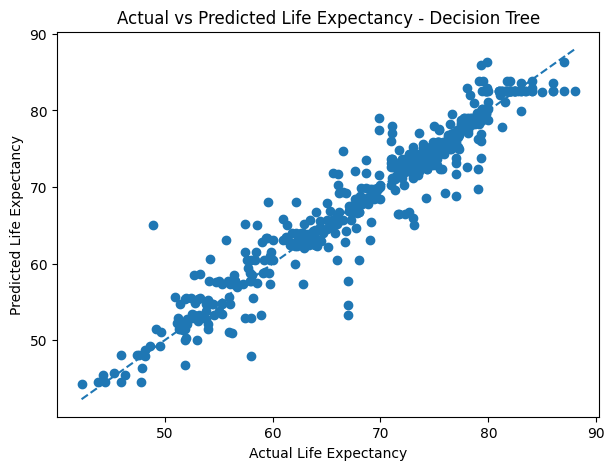

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_dt)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted Life Expectancy - Decision Tree")

plt.show()

Visualising the errors

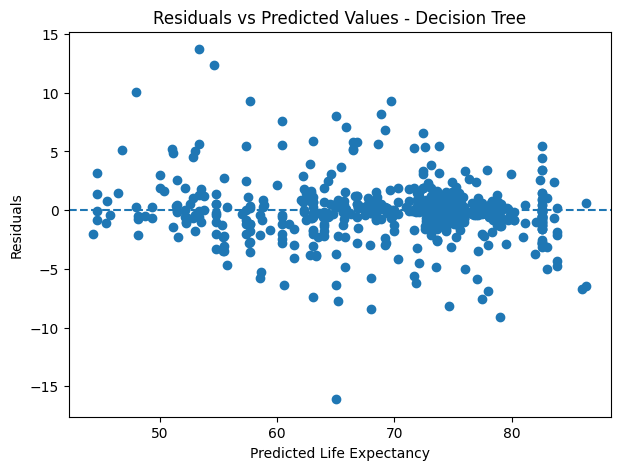

In [ ]:
residuals_dt = y_test - y_pred_dt

plt.figure(figsize=(7, 5))

plt.scatter(y_pred_dt, residuals_dt)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Life Expectancy")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values - Decision Tree")

plt.show()

# Random Forest Regression

A Random Forest combines predictions from many Decision Trees. The aim is to reduce the variance of a single tree while retaining the ability to model nonlinear relationships.


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MAE: {mae_rf:.2f} years")
print(f"Random Forest RMSE: {rmse_rf:.2f} years")
print(f"Random Forest R²: {r2_rf:.2f}")


Random Forest MAE: 1.05 years
Random Forest RMSE: 1.68 years
Random Forest R²: 0.97


### Random Forest: training vs test performance

As with the Decision Tree, training performance should be compared with test performance. A very large gap can indicate overfitting.


In [ ]:
y_train_pred_rf = rf_model.predict(X_train)

print("Training R²:", r2_score(y_train, y_train_pred_rf))
print("Test R²:", r2_score(y_test, y_pred_rf))
print("Training MAE:", mean_absolute_error(y_train, y_train_pred_rf))
print("Test MAE:", mean_absolute_error(y_test, y_pred_rf))


Training R²: 0.9947474736212762
Test R²: 0.9673081951125089
Training MAE: 0.42955465414176036
Test MAE: 1.0451740614334495


## Hyperparameter Tuning and Cross-Validation

The initial models used selected hyperparameter values. To make model selection more rigorous, hyperparameters are now tuned using **5-fold cross-validation on the training data only**. The test set is kept untouched until the final evaluation.

For each candidate model, the preprocessing steps are included inside the pipeline, so imputation, scaling and encoding are fitted separately within each cross-validation fold. The tuning criterion is **negative mean squared error**, so the parameter combination with the lowest cross-validated MSE is selected.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Ridge: tune the strength of L2 regularization
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

ridge_param_grid = {
    "regressor__alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

ridge_model = ridge_grid.best_estimator_
y_pred_ridge = ridge_model.predict(X_test)

print("Best Ridge alpha:", ridge_grid.best_params_["regressor__alpha"])
print(f"Best Ridge CV RMSE: {np.sqrt(-ridge_grid.best_score_):.3f} years")


Best Ridge alpha: 10
Best Ridge CV RMSE: 3.756 years


In [ ]:
# Lasso: tune the strength of L1 regularization
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Lasso(max_iter=10000))
])

lasso_param_grid = {
    "regressor__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

lasso_model = lasso_grid.best_estimator_
y_pred_lasso = lasso_model.predict(X_test)

print("Best Lasso alpha:", lasso_grid.best_params_["regressor__alpha"])
print(f"Best Lasso CV RMSE: {np.sqrt(-lasso_grid.best_score_):.3f} years")


Best Lasso alpha: 0.01
Best Lasso CV RMSE: 3.756 years


In [ ]:
# Decision Tree: tune tree complexity
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=42))
])

dt_param_grid = {
    "regressor__max_depth": [5, 8, 10, 12, 15],
    "regressor__min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    dt_pipeline,
    dt_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

dt_model = dt_grid.best_estimator_
y_pred_dt = dt_model.predict(X_test)

print("Best Decision Tree parameters:", dt_grid.best_params_)
print(f"Best Decision Tree CV RMSE: {np.sqrt(-dt_grid.best_score_):.3f} years")


Best Decision Tree parameters: {'regressor__max_depth': 8, 'regressor__min_samples_leaf': 2}
Best Decision Tree CV RMSE: 2.625 years


In [ ]:
# Random Forest: tune the main ensemble and tree-complexity parameters
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [None, 10, 20],
    "regressor__min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

rf_model = rf_grid.best_estimator_
y_pred_rf = rf_model.predict(X_test)

print("Best Random Forest parameters:", rf_grid.best_params_)
print(f"Best Random Forest CV RMSE: {np.sqrt(-rf_grid.best_score_):.3f} years")


Best Random Forest parameters: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 200}
Best Random Forest CV RMSE: 1.932 years


### Why the test set is not used during tuning

The test set is reserved for the final evaluation. Cross-validation repeatedly splits only the training data into training and validation folds. This prevents the test-set results from influencing the choice of hyperparameters and gives a more reliable estimate of how the selected model generalizes.


In [ ]:
# Final test-set evaluation of the tuned models
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Tuned Ridge:", f"MAE={mae_ridge:.2f}, RMSE={rmse_ridge:.2f}, R²={r2_ridge:.3f}")
print("Tuned Lasso:", f"MAE={mae_lasso:.2f}, RMSE={rmse_lasso:.2f}, R²={r2_lasso:.3f}")
print("Tuned Decision Tree:", f"MAE={mae_dt:.2f}, RMSE={rmse_dt:.2f}, R²={r2_dt:.3f}")
print("Tuned Random Forest:", f"MAE={mae_rf:.2f}, RMSE={rmse_rf:.2f}, R²={r2_rf:.3f}")


Tuned Ridge: MAE=2.83, RMSE=3.68, R²=0.843
Tuned Lasso: MAE=2.84, RMSE=3.68, R²=0.843
Tuned Decision Tree: MAE=1.73, RMSE=2.50, R²=0.928
Tuned Random Forest: MAE=1.04, RMSE=1.70, R²=0.967


### Cross-Validation Summary

The table below records the best 5-fold cross-validation RMSE obtained during hyperparameter tuning. These values are calculated from the training data only.


In [ ]:
cv_summary = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "Decision Tree", "Random Forest"],
    "Best CV RMSE (years)": [
        np.sqrt(-ridge_grid.best_score_),
        np.sqrt(-lasso_grid.best_score_),
        np.sqrt(-dt_grid.best_score_),
        np.sqrt(-rf_grid.best_score_)
    ]
})

cv_summary.round(3)


,Model,Best CV RMSE (years)
0,Ridge,3.756
1,Lasso,3.756
2,Decision Tree,2.625
3,Random Forest,1.932


## Model Comparison

The final models are compared on the untouched test set using MAE, RMSE and R². For this regression problem, lower MAE and RMSE indicate smaller prediction errors, while higher R² indicates that more variation in the target is explained by the model.

Adjusted R² is reported for Linear Regression, Ridge and Lasso because it is primarily useful for models expressed through a fixed set of regression predictors. For tree-based models, MAE, RMSE and R² are used as the main evaluation measures.


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "Decision Tree", "Random Forest"],
    "MAE (years)": [mae, mae_ridge, mae_lasso, mae_dt, mae_rf],
    "RMSE (years)": [rmse, rmse_ridge, rmse_lasso, rmse_dt, rmse_rf],
    "R²": [r2, r2_ridge, r2_lasso, r2_dt, r2_rf],
    "Adjusted R²": [adjusted_r2, adjusted_r2_ridge, adjusted_r2_lasso, np.nan, np.nan]
})

comparison.round({"MAE (years)": 2, "RMSE (years)": 2, "R²": 3, "Adjusted R²": 3})


,Model,MAE (years),RMSE (years),R²,Adjusted R²
0,Linear Regression,2.83,3.68,0.843,0.838
1,Ridge,2.83,3.68,0.843,0.838
2,Lasso,2.84,3.68,0.843,0.838
3,Decision Tree,1.73,2.50,0.928,NaN
4,Random Forest,1.04,1.70,0.967,NaN


"The skewness transformations improved the performance of the linear models, particularly Linear Regression and Ridge, while the effect on tree-based models was negligible. This is consistent with the fact that linear models can be more sensitive to the functional form of predictors, whereas tree-based models are generally less affected by monotonic transformations."

## Final Interpretation

The final comparison is based on models whose hyperparameters, where applicable, were selected using 5-fold cross-validation on the training data. The test set was then used once for final performance evaluation.

Linear Regression provides an interpretable baseline, while Ridge and Lasso control coefficient size through L2 and L1 regularization. The Decision Tree and Random Forest can capture nonlinear relationships and interactions that linear models cannot represent directly.

The final model should be assessed using MAE, RMSE and R² together with the cross-validation results and the training-versus-test performance. A lower MAE/RMSE means smaller prediction errors, while a higher R² indicates that more variation in life expectancy is explained by the model.

These models identify predictive associations in the available country-year data. They do **not** establish that a particular health, economic or demographic variable causes changes in life expectancy.


## Limitations

- The dataset contains repeated observations for the same countries across multiple years. A random train-test split can therefore place observations from the same country in both sets, which may make test performance more optimistic than performance on a completely unseen country.
- The data cover 2000–2015, so the model should not automatically be assumed to represent current conditions.
- Missing values were handled through training-set imputation rather than being treated as additional information.
- Some predictors are strongly related to one another. VIF-based feature reduction was used for the linear-model workflow, but correlation does not by itself imply causation.
- Outliers were investigated and retained when they appeared to represent plausible real-world country-year observations rather than data errors.
- The dataset is observational, so the model should be interpreted as a prediction model rather than a causal model.


## Conclusion

This project developed a regression workflow for predicting country-year life expectancy from health, economic and demographic indicators. After exploratory analysis, missing-value handling, outlier investigation and multicollinearity assessment, several regression approaches were evaluated.

Linear Regression, Ridge and Lasso provided useful baselines. Decision Tree and Random Forest models were then used to capture nonlinear relationships. Hyperparameters for Ridge, Lasso, Decision Tree and Random Forest were tuned using 5-fold cross-validation on the training data, while the test set was reserved for final evaluation.

The final model should be selected by considering test-set predictive performance, cross-validation performance, model complexity and overfitting behaviour. The results describe predictive relationships in this dataset and should not be interpreted as causal effects.
